XGBoost:-
Builds many small decision trees sequentially, each new tree tries to correct errors made by the existing collection of trees.

1.where a linear model is not  suitable
2.use XGBoost to model non-linearity
3.Backtest a simple strategy based on our XGBoost model to evaluate feasability - both as a maker and taker strat



In [2]:
import pandas as pd 
import numpy as np

In [7]:
df = pd.read_csv("C:/Users/Mritunjay Maddhesiya/OneDrive/Desktop/Research_Paper/11_Forecasting_Position_Model/data/XAU_Daily_20_26.csv")
#df = pd.read_csv("C:/Users/Mritunjay Maddhesiya/OneDrive/Desktop/Research_Paper/4_Time_Series/1m_SOL.csv")
#df["Date"]    = pd.to_datetime(df["Date"], format="%d-%m-%Y ",errors="coerce")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df  = df.rename(columns={"Price": "Close", "Vol.": "Volume"})
price_columns = ["Open", "High", "Low", "Close"]

for col in price_columns:
    df[col] = (df[col].astype(str).str.replace(",","",regex=False))
    df[col] = pd.to_numeric(df[col], errors="coerce")
df['return'] = df['Close'].pct_change()
df['weekday'] = df['Date'].dt.day_of_week
df.dropna(inplace=True)
df.head(10)

C:\TEMP.txt\ipykernel_16668\2742067968.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


,Date,Close,Open,High,Low,Volume,Change %,return,weekday
1,2020-01-03,1552.4,1531.7,1556.6,1530.4,436.74K,1.59%,0.015902,4
2,2020-01-06,1568.8,1562.7,1590.9,1562.3,558.97K,1.06%,0.010564,0
3,2020-01-07,1574.3,1567.4,1579.2,1557.0,435.87K,0.35%,0.003506,1
4,2020-01-08,1560.2,1578.8,1613.3,1553.4,813.41K,-0.90%,-0.008956,2
5,2020-01-09,1554.3,1557.7,1562.4,1541.0,372.88K,-0.38%,-0.003782,3
6,2020-01-10,1560.1,1553.4,1564.1,1546.7,344.34K,0.37%,0.003732,4
7,2020-01-13,1550.6,1563.0,1563.1,1547.0,311.73K,-0.61%,-0.006089,0
8,2020-01-14,1544.6,1548.6,1549.5,1536.4,340.91K,-0.39%,-0.003869,1
9,2020-01-15,1554.0,1546.8,1558.8,1546.5,310.07K,0.61%,0.006086,2
10,2020-01-16,1550.5,1556.6,1558.2,1548.0,260.05K,-0.23%,-0.002252,3


In [ ]:
### Research Question:-
### Can the weekday be used as a signal

## Split data by time
i = int(len(df) * 0.75)
df_train, df_test = df.iloc[:i].copy(), df.iloc[i:].copy()

df_train

,Date,Close,Open,High,Low,Volume,Change %,return,weekday
1,2020-01-03,1552.4,1531.7,1556.6,1530.4,436.74K,1.59%,0.015902,4
2,2020-01-06,1568.8,1562.7,1590.9,1562.3,558.97K,1.06%,0.010564,0
3,2020-01-07,1574.3,1567.4,1579.2,1557.0,435.87K,0.35%,0.003506,1
4,2020-01-08,1560.2,1578.8,1613.3,1553.4,813.41K,-0.90%,-0.008956,2
5,2020-01-09,1554.3,1557.7,1562.4,1541.0,372.88K,-0.38%,-0.003782,3
...,...,...,...,...,...,...,...,...,...
1114,2024-12-05,2636.1,2661.9,2667.3,2634.5,167.17K,-1.06%,-0.010584,3
1115,2024-12-09,2673.3,2654.5,2687.0,2637.5,181.51K,1.41%,0.014112,0
1116,2024-12-10,2705.6,2669.8,2708.8,2669.8,264.99K,1.21%,0.012082,1
1117,2024-12-11,2741.5,2708.8,2743.8,2700.3,219.47K,1.33%,0.013269,2


In [5]:
df_test

,Date,Close,Open,High,Low,Volume,Change %,return,weekday
1119,2024-12-16,2657.0,2654.6,2669.7,2648.3,147.05K,-1.41%,-0.014137,0
1120,2024-12-17,2649.6,2657.2,2662.5,2634.3,156.33K,-0.28%,-0.002785,1
1121,2024-12-18,2640.8,2651.2,2654.3,2587.2,191.59K,-0.33%,-0.003321,2
1122,2024-12-19,2596.0,2586.0,2625.0,2585.9,153.57K,-1.70%,-0.016965,3
1123,2024-12-23,2615.5,2627.3,2632.9,2610.2,53.37K,0.75%,0.007512,0
...,...,...,...,...,...,...,...,...,...
1490,2026-08-17,4473.7,4440.0,4486.5,4422.3,121.05K,0.82%,0.008203,0
1491,2026-08-18,4420.6,4473.4,4493.1,4383.3,131.15K,-1.19%,-0.011869,1
1492,2026-08-19,4545.3,4391.4,4582.8,4378.0,250.48K,2.82%,0.028209,2
1493,2026-08-20,4571.4,4580.0,4597.1,4506.0,186.48K,0.57%,0.005742,3


In [8]:
df_train.groupby('weekday').aggregate({'return':['mean', 'std']})

return          
             mean       std
weekday                    
0        0.000743  0.013044
1        0.001046  0.010166
2       -0.000115  0.008650
3        0.001152  0.010889
4       -0.000661  0.011608

In [ ]:
### Train XGBoost
import xgboost as xgb

model = xgb.XGBRegressor(max_depth=3, learning_rate=0.3)
model.fit(df_train[['weekday']], df_train['return'])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.3, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [10]:
tree_idx = 0
print(model.get_booster().get_dump(with_stats=True)[tree_idx])

0:[weekday<4] yes=1,no=2,missing=2,gain=0.00018609644,cover=1118
	1:[weekday<3] yes=3,no=4,missing=4,gain=6.71341695e-05,cover=1006
		3:[weekday<2] yes=5,no=6,missing=6,gain=0.000173947687,cover=755
			5:leaf=9.96282324e-05,cover=498
			6:leaf=-0.000203773889,cover=257
		4:leaf=0.000175040623,cover=251
	2:leaf=-0.000365053769,cover=112



In [11]:
y_hat = model.predict(df_test[['weekday']])
df_test['y_hat'] = y_hat
df_test[['weekday', 'return', 'y_hat']]

,weekday,return,y_hat
1119,0,-0.014137,0.000783
1120,1,-0.002785,0.000982
1121,2,-0.003321,-0.000059
1122,3,-0.016965,0.001087
1123,0,0.007512,0.000783
...,...,...,...
1490,0,0.008203,0.000783
1491,1,-0.011869,0.000982
1492,2,0.028209,-0.000059
1493,3,0.005742,0.001087


In [13]:
df_test['signal'] = np.sign(df_test['y_hat'])
df_test['trade_return'] = df_test['signal'] * df_test['return']
df_test[['weekday', 'return', 'y_hat', 'signal', 'trade_return']]

,weekday,return,y_hat,signal,trade_return
1119,0,-0.014137,0.000783,1.0,-0.014137
1120,1,-0.002785,0.000982,1.0,-0.002785
1121,2,-0.003321,-0.000059,-1.0,0.003321
1122,3,-0.016965,0.001087,1.0,-0.016965
1123,0,0.007512,0.000783,1.0,0.007512
...,...,...,...,...,...
1490,0,0.008203,0.000783,1.0,0.008203
1491,1,-0.011869,0.000982,1.0,-0.011869
1492,2,0.028209,-0.000059,-1.0,-0.028209
1493,3,0.005742,0.001087,1.0,0.005742


In [15]:
df_test['trade_return'].mean()

-0.0005707731350789577

In [18]:
(df_test['trade_return'] > 0).mean()

0.4477211796246649

<Axes: title={'center': 'Gross Pnl'}>

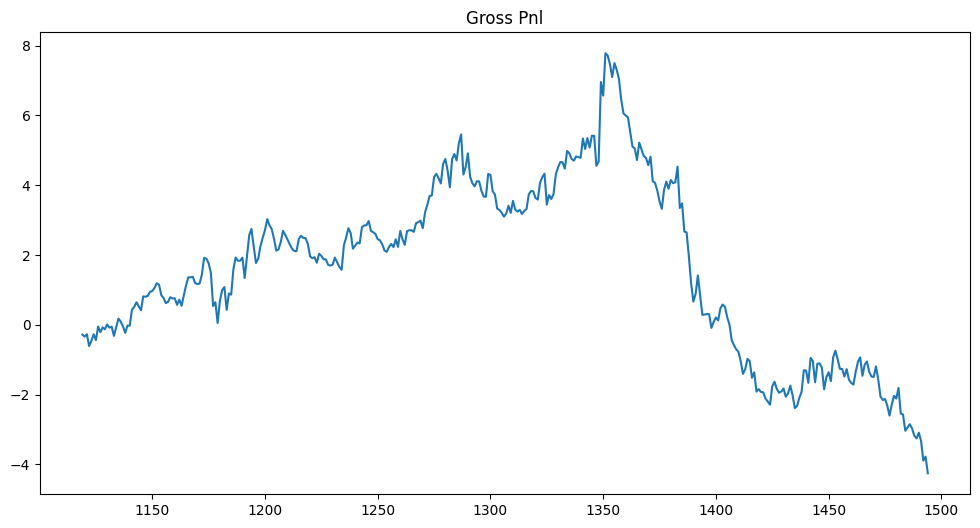

In [16]:
trade_size = 20
df_test['trade_gross_pnl'] = df_test['trade_return'] * trade_size
df_test['trade_gross_pnl'].cumsum().plot(title='Gross Pnl', figsize=(12,6))

<Axes: title={'center': 'Net Pnl'}>

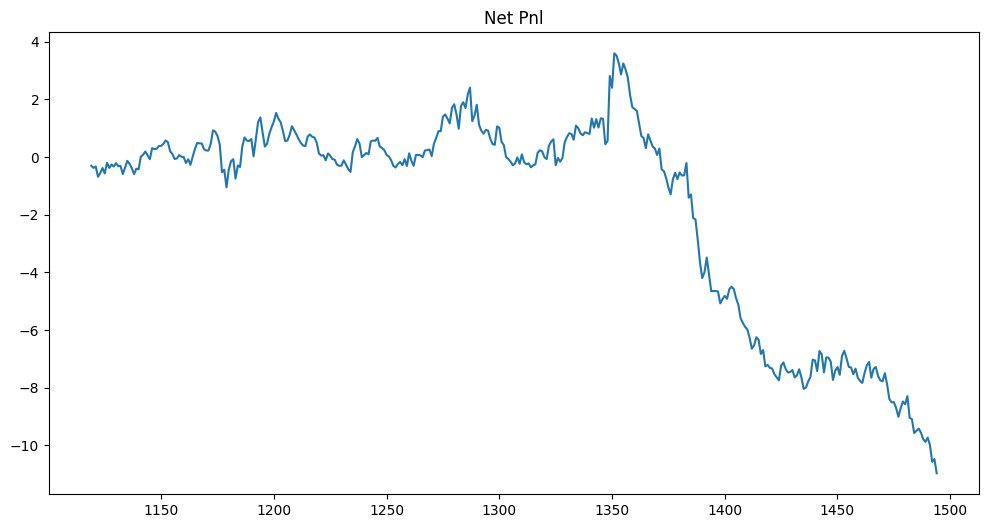

In [19]:
taker_fee = 0.00045

df_test['entry_value'] = trade_size
df_test['exit_value']  = trade_size + df_test['trade_gross_pnl']
df_test['taker_fee']   = (df_test['entry_value'] + df_test['exit_value']) * taker_fee
df_test['trade_net_pnl'] = df_test['trade_gross_pnl'] - df_test['taker_fee']
df_test['trade_net_pnl'].cumsum().plot(title='Net Pnl', figsize=(12, 6))

In [20]:
df_test['trade_net_pnl'].sum()

-10.970051502274561

In [21]:
df_test['trade_net_pnl'].sum()/trade_size

-0.548502575113728

Conclusion:-
1.Shown that the weekday does provide a predictable signal
2.some data doesn't fit a linear regression
3.I am not shy to use non-linear models and not married to linear models.